In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
klein = sc.read_h5ad('klein_paga.h5ad')
klein

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
from scipy.io import mmread
from scipy.sparse import csr_matrix, save_npz, load_npz

clones = load_npz('clone_meta.npz')
clones

<130887x5864 sparse matrix of type '<class 'numpy.int64'>'
	with 49302 stored elements in Compressed Sparse Row format>

### Initial Analysis by Melania

In [4]:
klein.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono
3,6.0,LK,Neutrophil,2,6.0,12,Neutrophil_12,early_prog_Neu
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery
...,...,...,...,...,...,...,...,...
130882,6.0,LSK,undiff,1,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast
130883,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2
130884,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono
130885,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono


In [6]:
klein.obs['Time_point'] = klein.obs['Time_point'].astype('category')

In [10]:
pd.crosstab(klein.obs.leiden, klein.obs.Annotation)

Annotation,Baso,Ccr7_DC,Eos,Erythroid,Lymphoid,Mast,Meg,Monocyte,Neutrophil,pDC,undiff
leiden,,,,,,,,,,,
0,0,0,0,0,0,0,0,1,0,0,14687
1,0,0,0,0,0,0,0,2,667,0,8755
2,0,0,0,0,0,0,0,8481,2,0,217
3,0,0,0,0,0,0,0,5819,15,0,2499
4,7607,0,74,0,0,0,0,12,7,0,245
5,0,0,0,0,856,0,0,4,0,100,6778
6,0,0,0,0,0,0,0,75,1,0,7215
7,0,0,0,0,0,0,0,0,6609,0,0
8,0,0,0,0,0,0,0,0,3038,0,3696


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


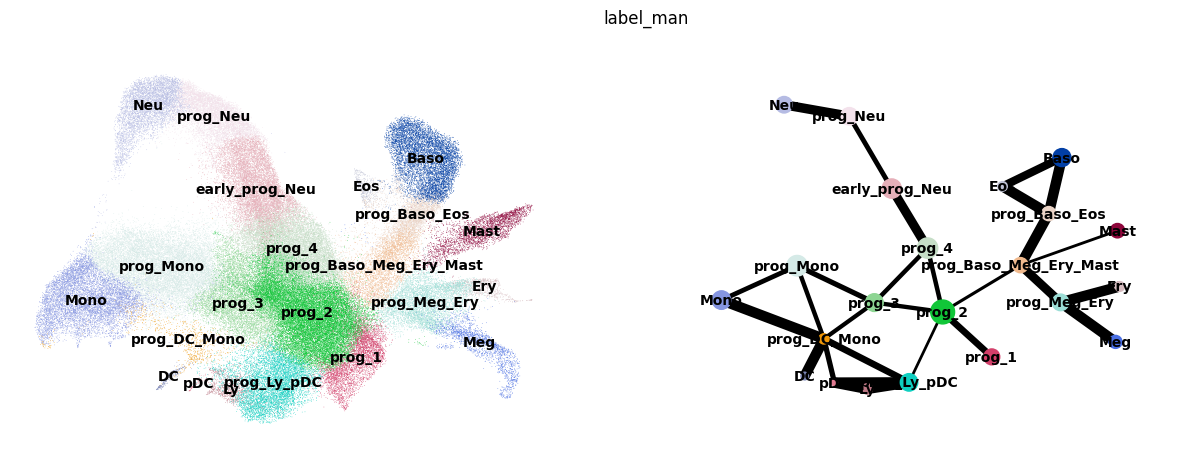

In [14]:
sc.pl.paga_compare(klein, threshold=0.25)

### Map Clonal IDs

In [7]:
clones_used = clones.todense()[np.array([int(item) for item in klein.obs.index])]
clones_used.shape

(126861, 5864)

In [8]:
index, ids = np.where(clones_used != 0)
clones_label = []

for idx in range(klein.shape[0]):
    clones_label.append(f'Clone_{ids[np.where(index == idx)[0][0]]}' if idx in index else 'Clone_nan')

In [9]:
klein.obs['clones'] = clones_label
klein.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394
3,6.0,LK,Neutrophil,2,6.0,12,Neutrophil_12,early_prog_Neu,Clone_nan
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972
...,...,...,...,...,...,...,...,...,...
130882,6.0,LSK,undiff,1,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_nan
130883,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2,Clone_1374
130884,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan
130885,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan


In [18]:
klein.obs[klein.obs['clones'] != 'Clone_nan'].shape

(47979, 9)

In [19]:
np.unique(klein.obs['clones'].values).shape

(5860,)

### Generate Clonal Matrix

In [10]:
adata_clone = klein.obs[klein.obs['clones'] != 'Clone_nan']
adata_clone['pop_time'] = adata_clone['label_man'].astype(str) + '_' + adata_clone['Time_point'].astype(str)
adata_clone = adata_clone.drop(labels=['time_cat', 'leiden', 'comb'], axis=1)
adata_clone

/tmp/ipykernel_4002390/2184172387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_clone['pop_time'] = adata_clone['label_man'].astype(str) + '_' + adata_clone['Time_point'].astype(str)


,Time_point,Population,Annotation,Well,label_man,clones,pop_time
0,6.0,LK,undiff,2,prog_2,Clone_573,prog_2_6.0
1,6.0,LK,undiff,2,prog_Baso_Meg_Ery_Mast,Clone_1440,prog_Baso_Meg_Ery_Mast_6.0
2,6.0,LK,Monocyte,2,prog_Mono,Clone_394,prog_Mono_6.0
4,6.0,LK,undiff,2,prog_Meg_Ery,Clone_1972,prog_Meg_Ery_6.0
6,6.0,LK,Neutrophil,2,prog_Neu,Clone_1450,prog_Neu_6.0
...,...,...,...,...,...,...,...
130875,6.0,LSK,undiff,1,prog_Meg_Ery,Clone_12,prog_Meg_Ery_6.0
130876,6.0,LSK,undiff,1,prog_2,Clone_267,prog_2_6.0
130877,6.0,LSK,Neutrophil,1,early_prog_Neu,Clone_3534,early_prog_Neu_6.0
130879,6.0,LSK,Monocyte,1,prog_Mono,Clone_4945,prog_Mono_6.0


In [11]:
df = adata_clone.groupby(by=['pop_time', 'clones']).size().reset_index(name='counts')
df = df.sort_values(by=['pop_time'])
df

,pop_time,clones,counts
0,Baso_2.0,Clone_5443,2
1,Baso_2.0,Clone_582,1
171,Baso_4.0,Clone_4473,6
172,Baso_4.0,Clone_4543,10
173,Baso_4.0,Clone_4548,1
...,...,...,...
17176,prog_Neu_6.0,Clone_2694,1
17175,prog_Neu_6.0,Clone_2693,1
17174,prog_Neu_6.0,Clone_2689,2
17172,prog_Neu_6.0,Clone_2671,5


In [12]:
df = df.pivot(index='clones', columns='pop_time', values='counts')
df.index.name = None
df.columns.name = None
df = df.fillna(0.0)
df

,Baso_2.0,Baso_4.0,Baso_6.0,DC_2.0,DC_4.0,DC_6.0,Eos_4.0,Eos_6.0,Ery_2.0,Ery_4.0,...,prog_Ly_pDC_6.0,prog_Meg_Ery_2.0,prog_Meg_Ery_4.0,prog_Meg_Ery_6.0,prog_Mono_2.0,prog_Mono_4.0,prog_Mono_6.0,prog_Neu_2.0,prog_Neu_4.0,prog_Neu_6.0
Clone_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
Clone_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clone_995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
Clone_996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,4.0
Clone_997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,3.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0


### Analysis of Clonal Infomation

In [13]:
klein.obs['Time_point'] = klein.obs['Time_point'].astype(str)

for time in ['2.0', '4.0', '6.0']:
    print (df[[i for i in df.columns if i.endswith(time)]].sum().sum())
    print (klein.obs[klein.obs['Time_point'].values == time].shape)

4558.0
(27757, 9)
14679.0
(47444, 9)
28742.0
(51660, 9)


In [14]:
mat = sc.AnnData(df, dtype=np.float32)
df.columns = mat.var.index
mat

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 5859 × 64

In [15]:
sc.pp.filter_cells(mat, min_counts=3)
sc.pp.filter_genes(mat, min_counts=1)
mat

AnnData object with n_obs × n_vars = 4214 × 62
    obs: 'n_counts'
    var: 'n_counts'

In [34]:
mat.X.sum().sum()

44756.0

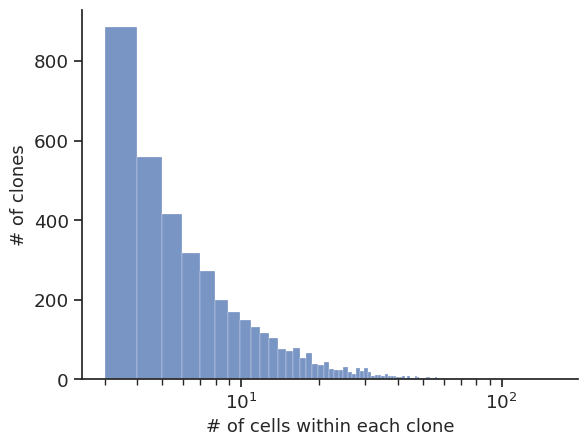

In [35]:
sns.set_theme(style='ticks', font_scale=1.2)
ax = sns.histplot(mat.obs.n_counts.values)
plt.xscale('log')
plt.xlabel('# of cells within each clone', fontsize=13)
plt.ylabel('# of clones', fontsize=13)
ax.spines[['right', 'top']].set_visible(False)
# plt.savefig('./figures/cellnumber.svg', dpi=600, bbox_inches='tight', transparent=False, facecolor='white')

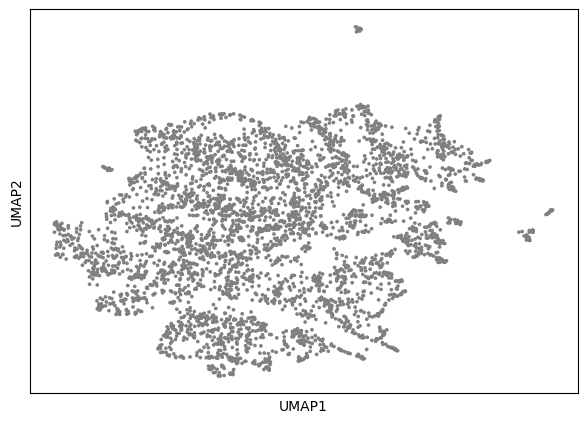

In [16]:
sc.tl.pca(mat)
sc.pp.neighbors(mat, n_neighbors=10, n_pcs=50)
sc.tl.umap(mat)
sc.pl.scatter(mat, basis='umap')

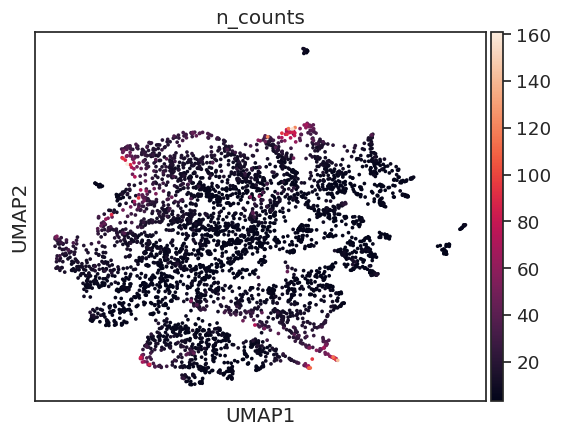

In [37]:
sc.pl.umap(mat, color='n_counts', legend_loc='on data')

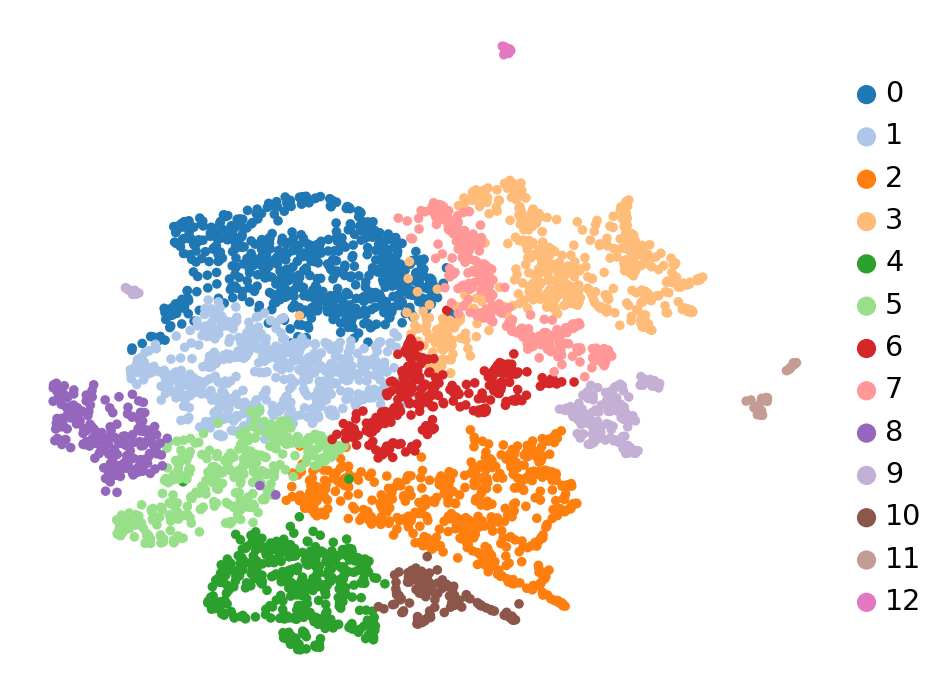

In [17]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(6, 5))
sc.tl.leiden(mat, resolution=0.25)
sc.pl.scatter(mat, basis='umap', color='leiden', legend_loc='right margin', size=75,
    title='', frameon=False, palette=sns.color_palette('tab20'))

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


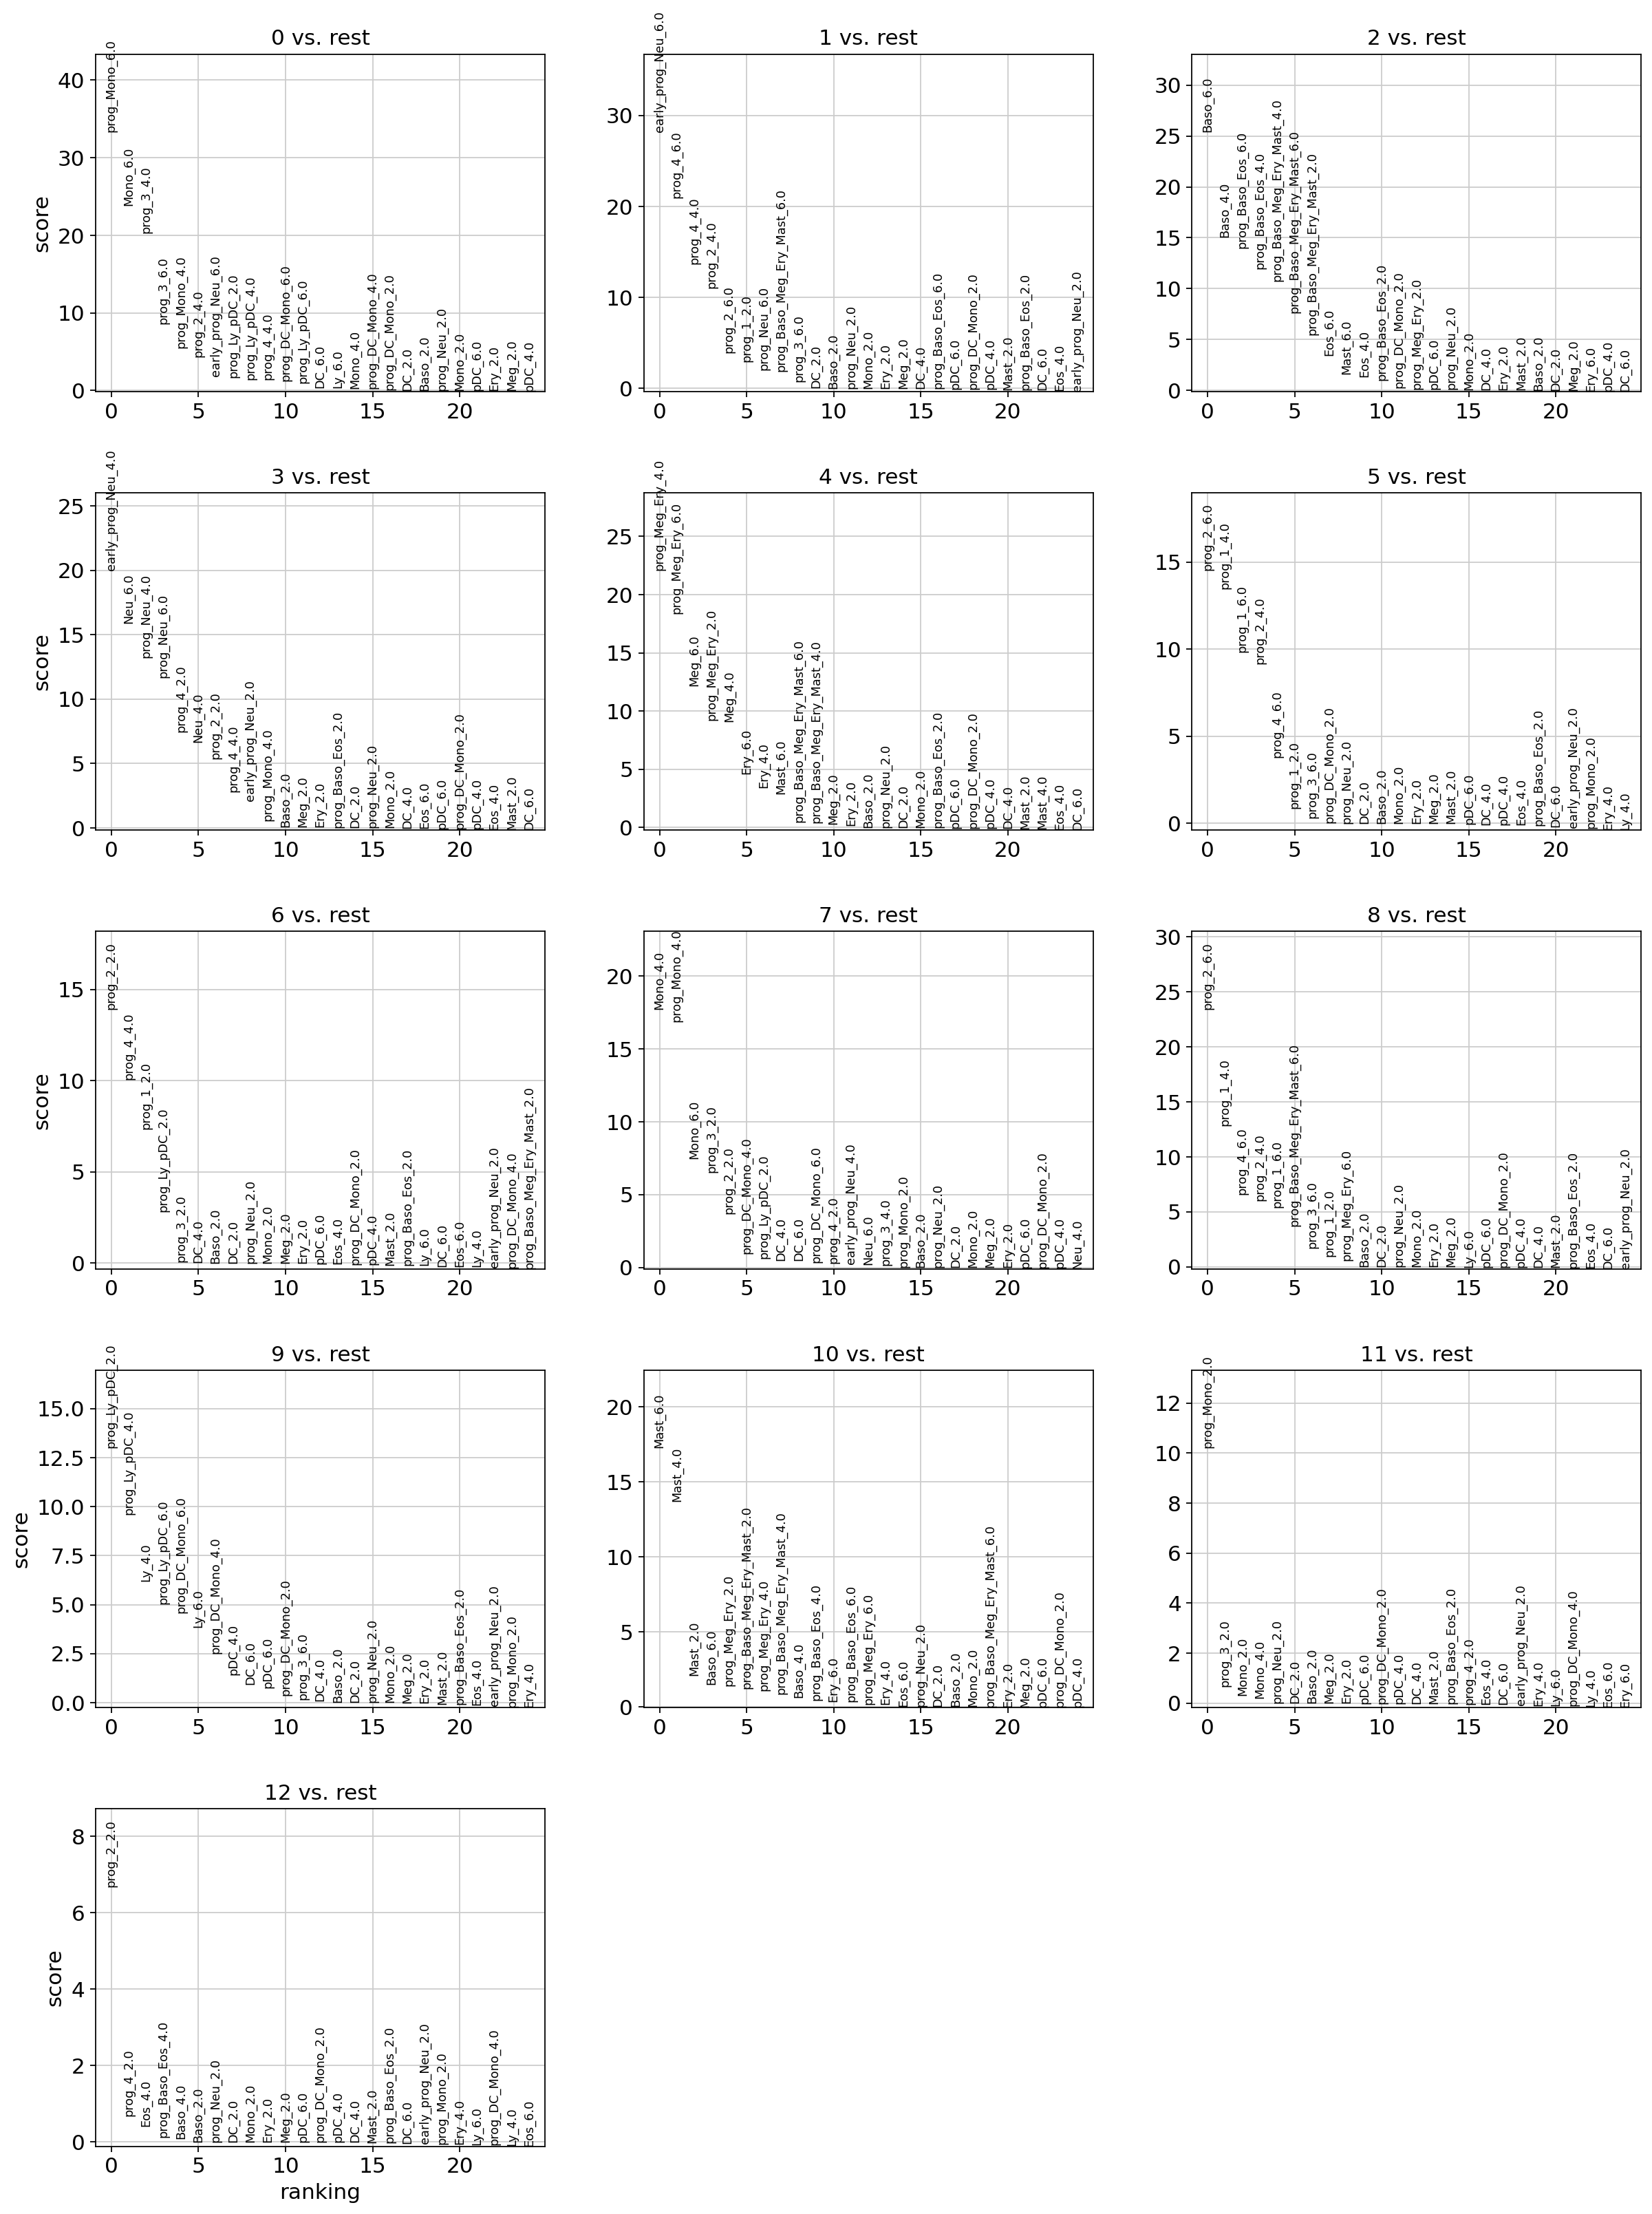

In [18]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(6, 5))
sc.tl.rank_genes_groups(mat, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(mat, n_genes=25, sharey=False, ncols=3)

In [40]:
init = pd.DataFrame(mat.obs.leiden.value_counts())
init.at[int(init.index[-1]) + 1, 'count'] = 5859
init.index.name = None
init.columns = ['leiden']
init['leiden'] = init['leiden'].astype(int)
# init.to_csv('./data/initial_condition.csv')

### UMAP related plots

In [19]:
adata_clone = klein[klein.obs['clones'] != 'Clone_nan', :]
adata_clone = adata_clone[adata_clone.obs['clones'].isin(mat.obs.index), :]
adata_clone

View of AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

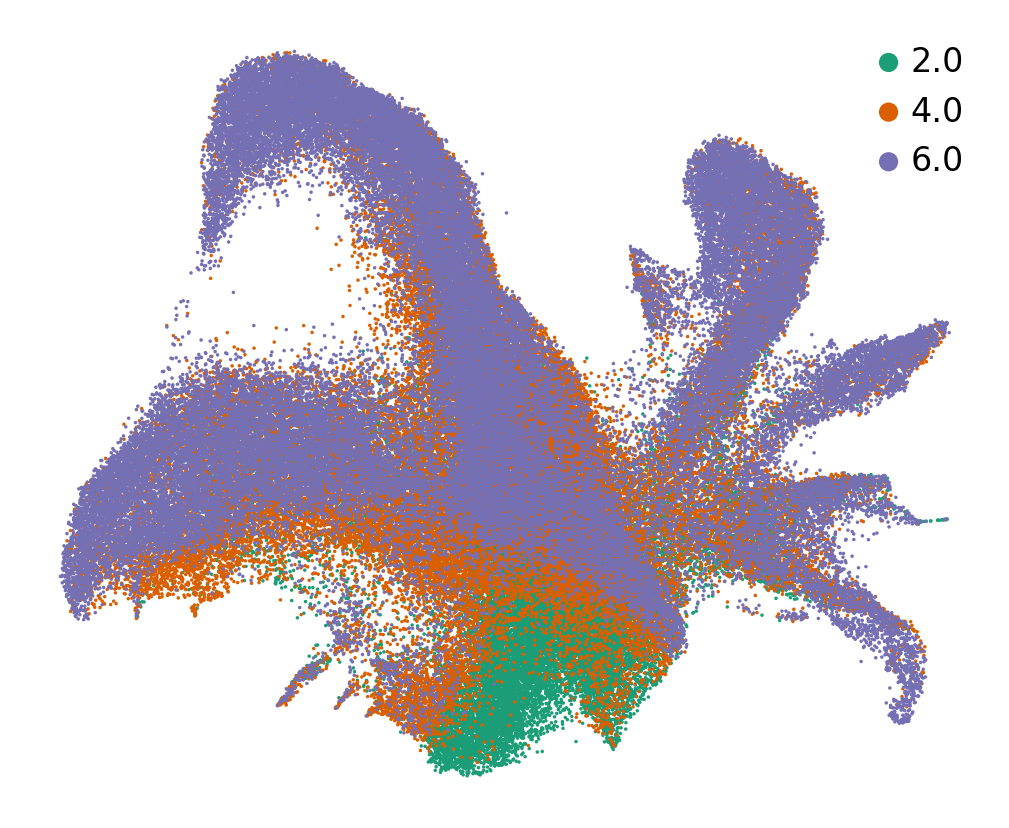

In [20]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(klein, basis='umap', color='Time_point', 
              legend_loc='best', palette=sns.color_palette('Dark2'), 
              save='timepoints.svg', size=10, frameon=False, title='',
              legend_fontsize=15)

In [21]:
leiden = []
for clone in adata_clone.obs['clones'].values:
    leiden.append(mat.obs.loc[clone]['leiden'])
adata_clone.obs['meta_clones'] = leiden

/tmp/ipykernel_4002390/520276951.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_clone.obs['meta_clones'] = leiden


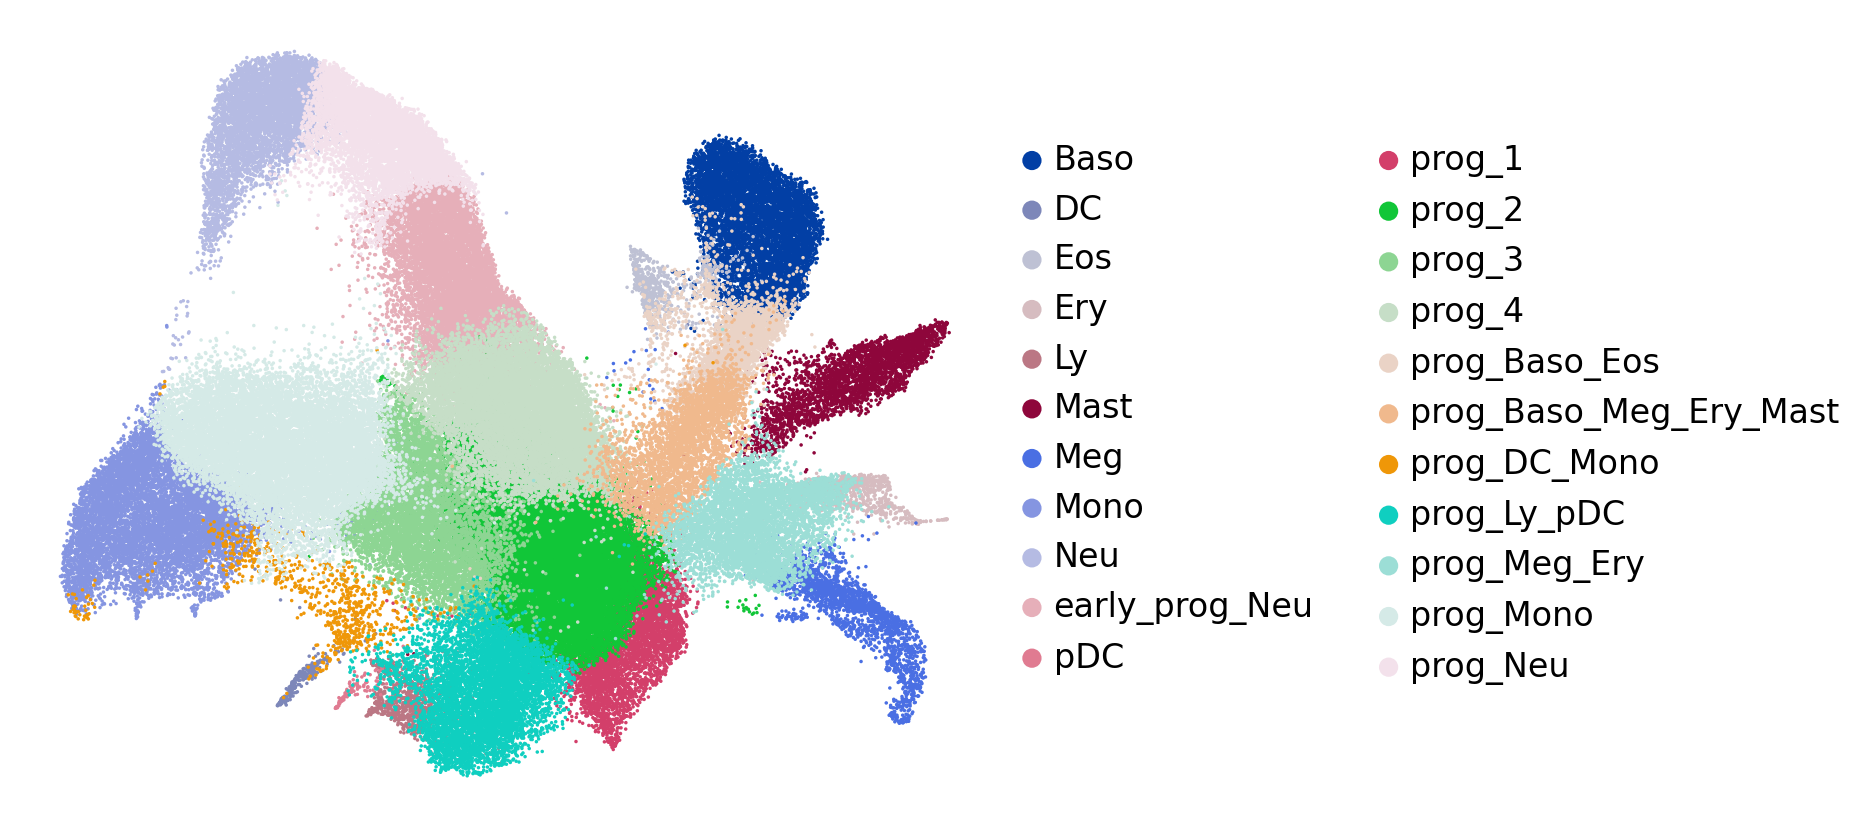

In [22]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(klein, basis='umap', color='label_man', 
              legend_loc='right margin', 
              save='populations.svg', size=10, frameon=False, 
              title='', legend_fontsize=15)

In [23]:
klein.obs['Meta clones'] = np.zeros(klein.shape[0]) - 1
for i in list(adata_clone.obs.index):
    klein.obs.at[i, 'Meta clones'] = adata_clone.obs.loc[i]['meta_clones']
klein.obs['Meta clones'] = [str(i) for i in klein.obs['Meta clones']]

/tmp/ipykernel_4002390/1922454633.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  klein.obs.at[i, 'Meta clones'] = adata_clone.obs.loc[i]['meta_clones']


In [24]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
klein.obs['group'] = pd.Categorical(klein.obs['Meta clones'], categories=group_labels)

In [50]:
klein.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573,8,8
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,8
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394,0,0
3,6.0,LK,Neutrophil,2,6.0,12,Neutrophil_12,early_prog_Neu,Clone_nan,-1.0,NaN
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,4
...,...,...,...,...,...,...,...,...,...,...,...
130882,6.0,LSK,undiff,1,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_nan,-1.0,NaN
130883,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2,Clone_1374,5,5
130884,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan,-1.0,NaN
130885,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan,-1.0,NaN


In [49]:
klein.write('./klein_update.h5ad')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


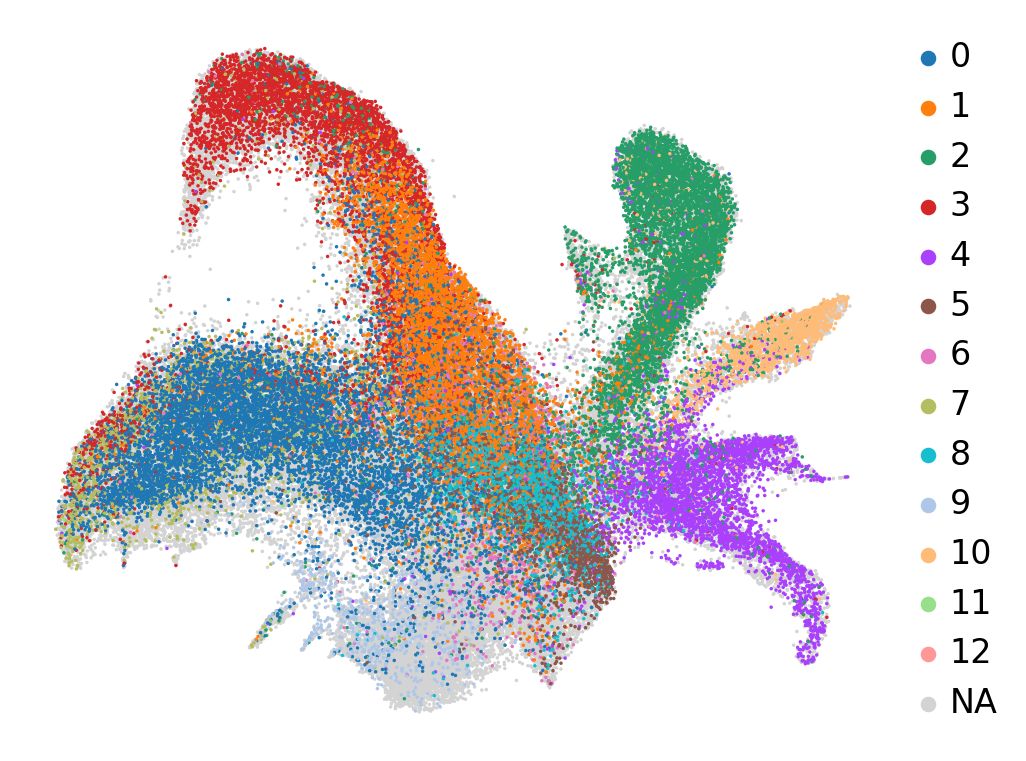

In [25]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(klein, groups=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], color=['group'],
            size=10, frameon=False, title='', legend_fontsize=15, save='metaclones')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


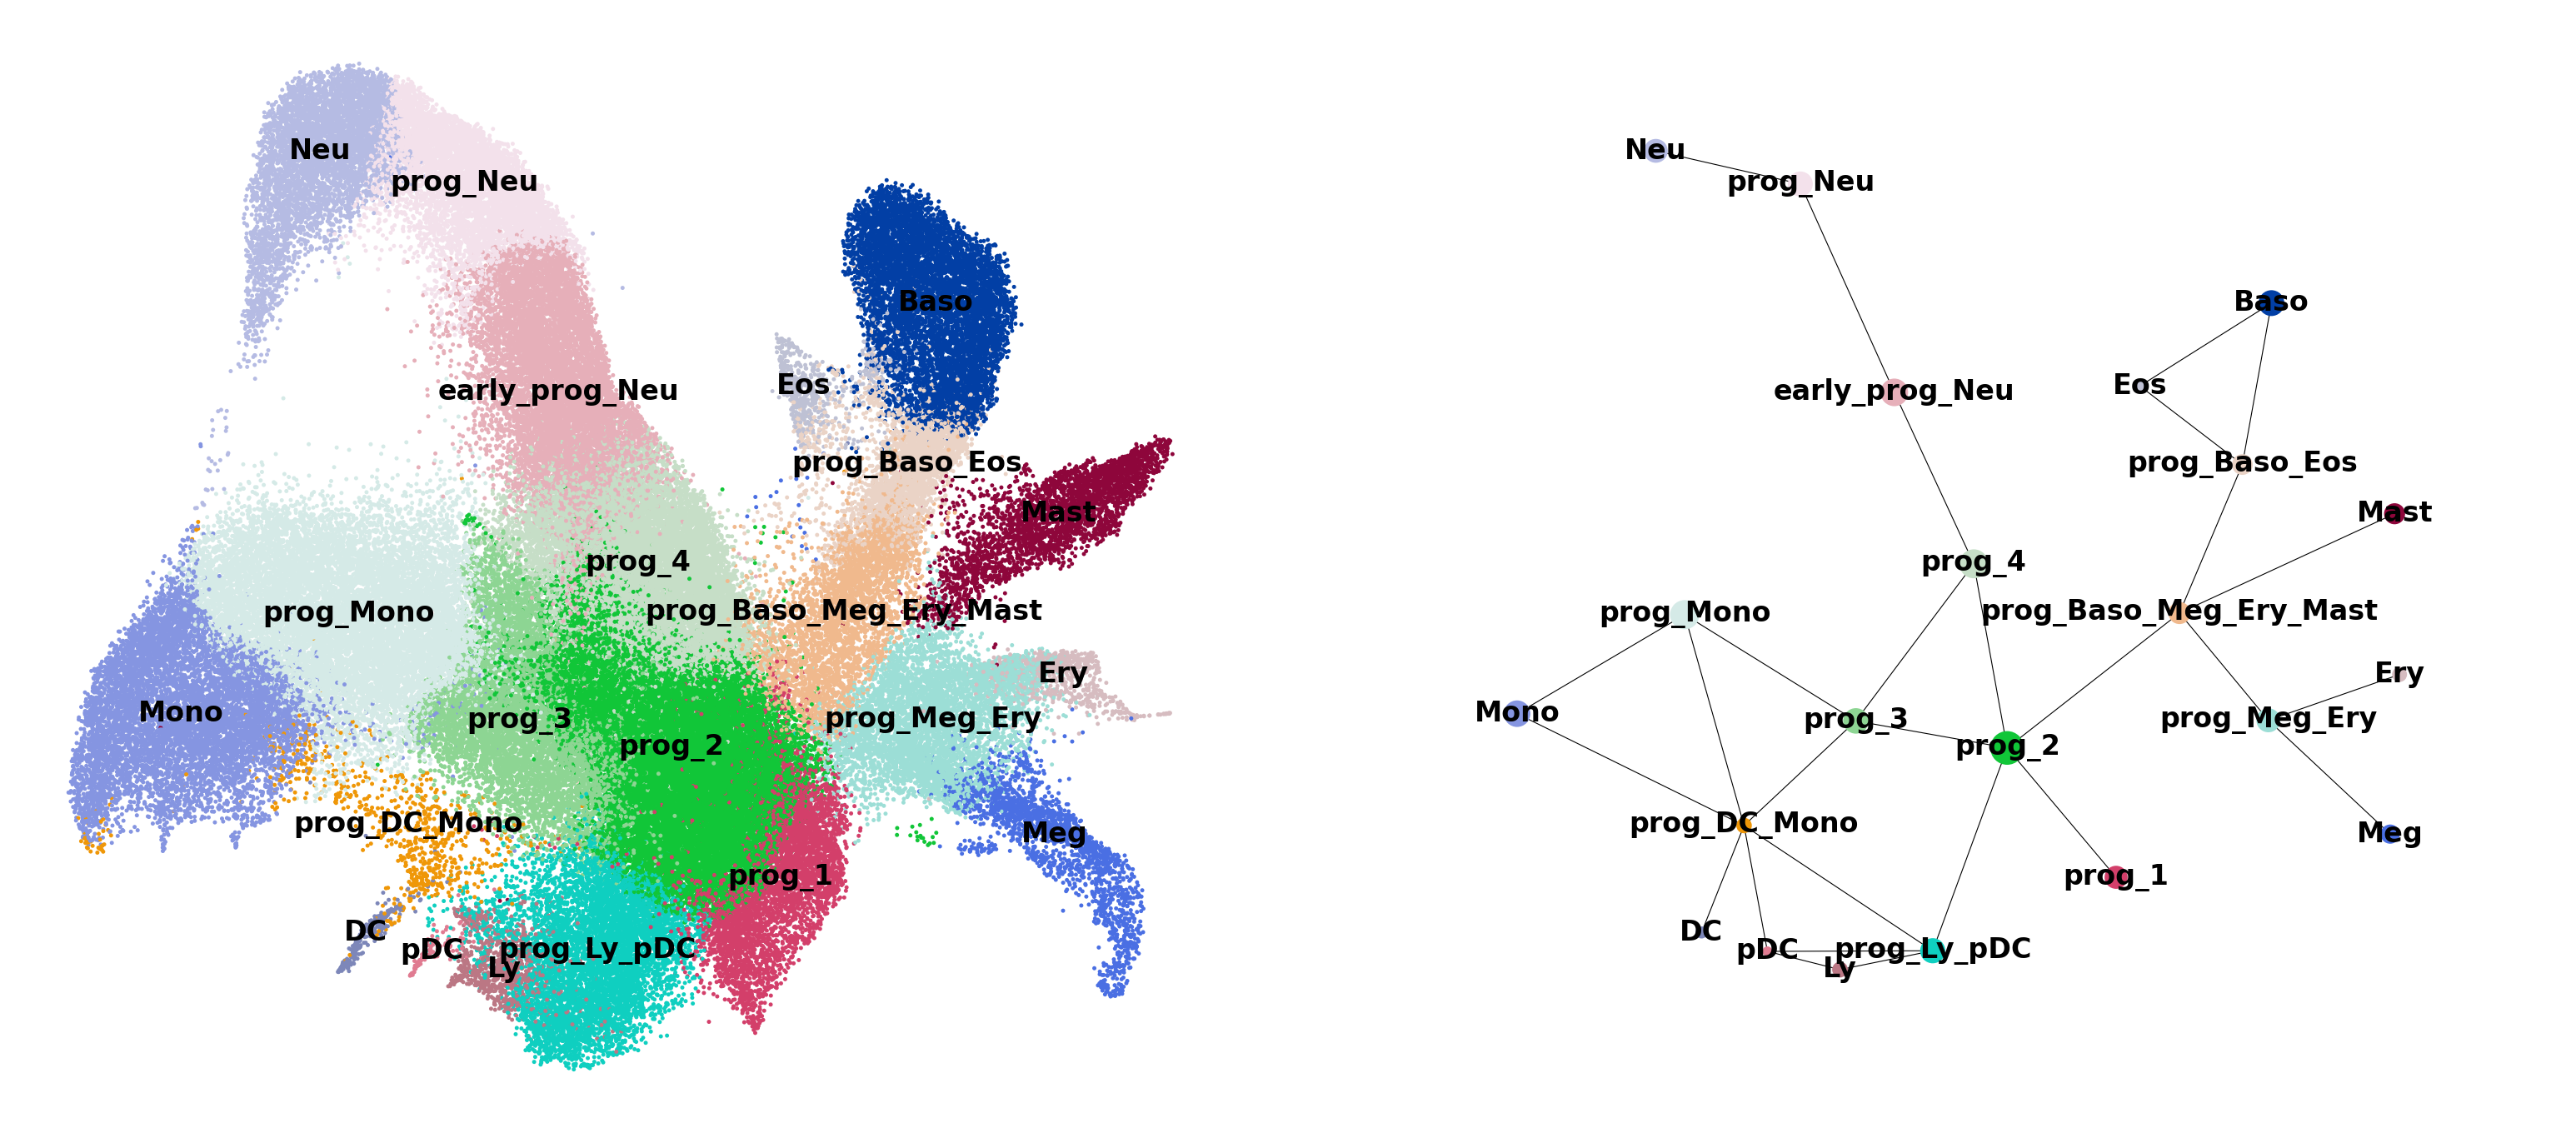

In [32]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(10, 10), transparent=True)
sc.pl.paga_compare(
    klein, basis='umap', threshold=0.25,
    save='_supp.svg', size=20, frameon=False, 
    title='', legend_fontsize=15, edge_width_scale=0.5, max_edge_width=0.5
    # labels=['' for i in range(len(set(klein.obs['label_man'])))]
)

In [ ]:
adata_clone.write('./adata_used.h5ad')

In [ ]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(7, 6))
hsc = adata_clone[adata_clone.obs['label_man'] == 'prog_1']
sc.pl.scatter(hsc, basis='umap', color=['meta_clones'],
              legend_loc='best', size=50, frameon=False, title='', legend_fontsize=14)

### Generate model inputs

In [ ]:
times = ['2.0', '4.0', '6.0']
size_leiden = len(set(mat.obs.leiden))
size_time = len(times)
size_pops = len(set(adata_clone.obs.label_man))
print (size_leiden, size_time, size_pops)

In [ ]:
print (adata_clone[adata_clone.obs['Time_point'].values == '2.0', :].shape)
print (adata_clone[adata_clone.obs['Time_point'].values == '4.0', :].shape)
print (adata_clone[adata_clone.obs['Time_point'].values == '6.0', :].shape)

In [ ]:
from natsort import natsorted
leiden = list(set(mat.obs.leiden))
leiden = natsorted(leiden)
leiden

In [ ]:
graph = pd.read_excel('./mingze_weinreb.xlsx', index_col=0)
graph = graph.fillna(0.0)
graph

In [ ]:
graph.to_csv('./graph_table.csv')

In [ ]:
adata_clone.obs

In [ ]:
scaling_factor = [1.0808, 3.1616, 8.7108]

In [ ]:
kinetics = np.zeros((size_leiden + 1, size_time, size_pops), dtype=np.float32)
pops = graph.columns

for idi, leid in enumerate(leiden):
    for idj, time in enumerate(times):
        for idk, pop in enumerate(pops):
            kinetics[idi, idj, idk] = int(adata_clone.obs[(adata_clone.obs['Time_point'] == time) & (adata_clone.obs['meta_clones'] == leid) & (adata_clone.obs['label_man'] == pop)].shape[0] * scaling_factor[idj])

In [ ]:
kinetics.sum()

In [ ]:
klein.obs

In [ ]:
for idj, time in enumerate(times):
    for idk, pop in enumerate(pops):
        kinetics[-1, idj, idk] = int(klein.obs[(klein.obs['Time_point'] == time) & (klein.obs['label_man'] == pop)].shape[0] * scaling_factor[idj])

In [ ]:
kinetics.sum()

In [ ]:
np.savetxt('./kinetics_array_correction_factor.txt', np.reshape(kinetics, (size_leiden + 1, size_time * size_pops)))

In [ ]:
anno = pd.DataFrame(data=graph.columns, columns=['populations'])
anno['clones'] = [f'Clone {item}' for item in range(len(anno))]
anno.to_csv('./annotations.csv', index=False)

In [ ]:
kinetics[-1, :, 0]

In [ ]:
temp = klein.obs[klein.obs['label_man'] == 'prog_1']
temp[temp['Time_point'] == '6.0']

In [ ]:
adata = sc.read_h5ad('adata_used.h5ad')
adata

In [ ]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(8, 6))
sc.pl.umap(adata, color=['label_man'], s=15, groups=['prog_1'], frameon=False, title='', save='prog_1')

In [ ]:
prog_1 = adata[adata.obs['label_man'] == 'prog_1', :]
prog_1

In [ ]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(8, 6))
sc.pl.umap(prog_1, color=['meta_clones'], s=100, frameon=False, title='', save='prog_1_0', groups=['0'])